In [97]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
from scipy.integrate import quad

### Part (a)

Converting the second order ODE to a system of two first order ODEs
$$
\dfrac{dy}{dt} = z
$$
$$
\dfrac{dz}{dt} = \lambda sinh(\lambda y)
$$

### Part (b)

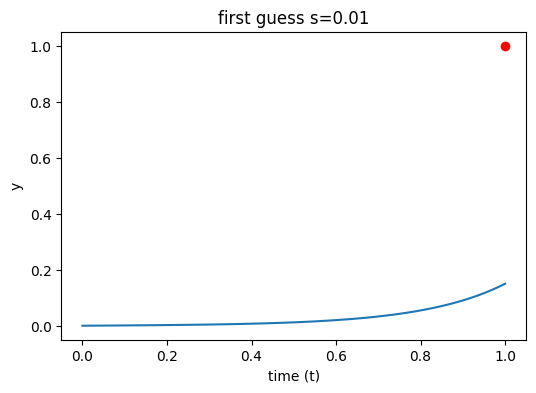

y(0):  0.15010235203633127


In [122]:
# Define the differential equation function F(t, s)
def F(t, s):
    y, v = s  # Extracting the variables y and v from the state vector s
    dydt = v
    dvdt = 5 * np.sinh(5 * y) 
    return [dydt, dvdt]

t_span = np.linspace(0, 1, 100)
y0 = 0
z0 = 0.01
t_eval = np.linspace(0, 1, 100)
sol = solve_ivp(F, [0, 1], [y0, z0], t_eval = t_eval)

plt.figure(figsize=(6, 4))
plt.plot(sol.t, sol.y[0])
plt.plot(1, 1, 'ro')
plt.xlabel('time (t)')
plt.ylabel('y')
plt.title(f'first guess s={z0}')
plt.show()

print("y(0): ", sol.y[0][-1])

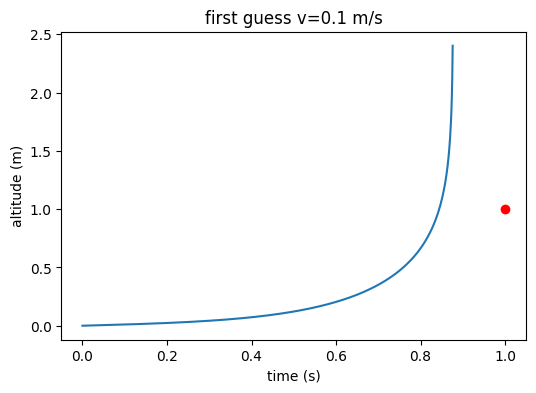

y(0):  [0.00000000e+00 1.00100518e-04 2.00203545e-04 3.00311586e-04
 4.00427150e-04 5.00552744e-04 6.00690876e-04 7.00844057e-04
 8.01014793e-04 9.01205595e-04 1.00141898e-03 1.10165810e-03
 1.20192583e-03 1.30222459e-03 1.40255680e-03 1.50292487e-03
 1.60333125e-03 1.70377838e-03 1.80426868e-03 1.90480461e-03
 2.00538861e-03 2.10602314e-03 2.20671066e-03 2.30745362e-03
 2.40825451e-03 2.50911579e-03 2.61003993e-03 2.71102942e-03
 2.81208675e-03 2.91321440e-03 3.01441487e-03 3.11569066e-03
 3.21704428e-03 3.31847823e-03 3.41999503e-03 3.52159720e-03
 3.62328726e-03 3.72506773e-03 3.82694115e-03 3.92891005e-03
 4.03097699e-03 4.13314449e-03 4.23541512e-03 4.33779142e-03
 4.44027597e-03 4.54287131e-03 4.64558003e-03 4.74840468e-03
 4.85134786e-03 4.95441215e-03 5.05760013e-03 5.16091439e-03
 5.26435753e-03 5.36793215e-03 5.47164085e-03 5.57548626e-03
 5.67947097e-03 5.78359762e-03 5.88786882e-03 5.99228720e-03
 6.09685540e-03 6.20157605e-03 6.30645180e-03 6.41148529e-03
 6.51667918e-03 6

In [124]:
y0 = 0
v0 = 0.1
t_eval = np.linspace(0, 1, 1000)
sol = solve_ivp(F, [0, 1], [y0, v0], t_eval = t_eval)

plt.figure(figsize=(6, 4))
plt.plot(sol.t, sol.y[0])
plt.plot(1, 1, 'ro')
plt.xlabel('time (s)')
plt.ylabel('altitude (m)')
plt.title(f'first guess v={v0} m/s')
plt.show()

print("y(0): ", sol.y[0])


In [128]:
def objective(v0):
    sol = solve_ivp(F, [0, 1], [y0, v0], t_eval = t_eval)
    y = sol.y[0]
    return y[-1] - 1

v0, = fsolve(objective, 0.01)
print(v0)

0.04575918818324071


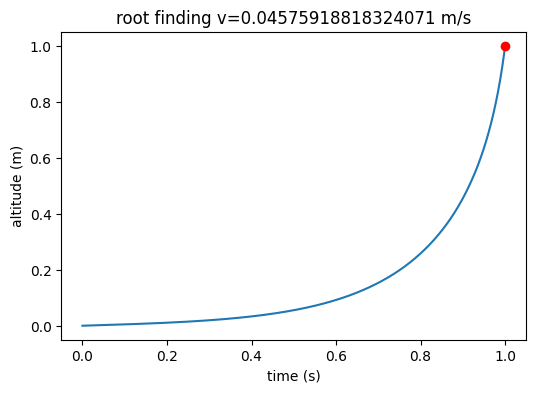

In [129]:
sol = solve_ivp(F, [0, 1], [y0, v0], t_eval = t_eval)

plt.figure(figsize = (6, 4))
plt.plot(sol.t, sol.y[0])
plt.plot(1, 1, 'ro')
plt.xlabel('time (s)')
plt.ylabel('altitude (m)')
plt.title(f'root finding v={v0} m/s')
plt.show()

In [102]:
# Define the function to integrate
def integrand(t, s):
    return 1 / np.sqrt(s**2 + 2 * np.cosh(t) - 2)

# Define function to evaluate ts numerically
def calculate_ts(s):
    lam = 5  # Parameter value
    result, _ = quad(integrand, 0, np.inf, args=(s,))
    return 1 / lam * result

# Calculate ts for s = 0.01 and s = 0.1
ts_001 = calculate_ts(0.01)
ts_01 = calculate_ts(0.1)

print("ts for s = 0.01:", ts_001)
print("ts for s = 0.1:", ts_01)


ts for s = 0.01: 1.3369294513950738
ts for s = 0.1: 0.876828646426834


/tmp/ipykernel_2429283/2656929324.py:3: RuntimeWarning: overflow encountered in cosh
  return 1 / np.sqrt(s**2 + 2 * np.cosh(t) - 2)
